<a href="https://colab.research.google.com/github/ervatoker/IOT-Erva-Toker/blob/main/IoTID20_TabM_RealMLP_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# CELL 1 — CONFIG

DO_MOUNT_DRIVE   = True
DO_DOWNLOAD      = True    # True for first time

DATASET_ID       = 'rohulaminlabid/iotid20-dataset'
DRIVE_CACHE      = '/content/drive/MyDrive/kagglehub_cache'
TARGET_ALIAS     = '/content/drive/MyDrive/datasets/iotid20'
DRIVE_OUT_DIR    = '/content/drive/MyDrive/iotid20_outputs'

#Model & Balancing Config
LABEL_COL        = 'Sub_Cat'
UNDERSAMPLE_TO   = 15_000
TEST_SIZE        = 0.20
VAL_SIZE         = 0.125      # 0.125 × 0.80 = 0.10 of total 70/10/20
RANDOM_STATE     = 42
DEVICE           = 'cuda'

N_EPOCHS_TABM    = 256
EARLY_STOPPING   = 20
BATCH_SIZE       = 512

In [2]:
# CELL 2 — INSTALL


!pip install -q pytabkit
!pip install -q tabm
!pip install -q kagglehub
!pip install -q scikit-learn pandas numpy matplotlib seaborn
print(' All packages installed restart runtime!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.0/364.0 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 33.0 MB/s eta 0:00:00
 All packages installed restart runtime!


In [3]:
# CELL 3 — IMPORTS + MOUNT + DOWNLOAD + GPU CHECK

import os, glob, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score,
                             confusion_matrix, classification_report)
from pytabkit import RealMLP_TD_Classifier
warnings.filterwarnings('ignore')

# GPU check
if not torch.cuda.is_available():
    raise RuntimeError(
        '\n\n NO GPU DETECTED!\n'
        '→ Runtime → Change runtime type → T4 GPU → Save\n')
device = torch.device(DEVICE)
print(f' GPU: {torch.cuda.get_device_name(0)}')
print(f' VRAM: {torch.cuda.get_device_properties(0).total_mem / 1e9:.1f} GB'  if hasattr(torch.cuda.get_device_properties(0), 'total_mem') else f'✅ VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

# Mount Drive
if DO_MOUNT_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    os.makedirs(DRIVE_OUT_DIR, exist_ok=True)
    print(' Drive mounted')

# Download
if DO_DOWNLOAD:
    import kagglehub
    os.makedirs(DRIVE_CACHE, exist_ok=True)
    os.environ['KAGGLE_CACHE_DIR'] = DRIVE_CACHE
    print('Downloading IoTID20...')
    path = kagglehub.dataset_download(DATASET_ID)
    print(f' Downloaded to: {path}')
    # Create alias symlink
    if not os.path.exists(TARGET_ALIAS):
        try:
            os.symlink(path, TARGET_ALIAS)
            print(f' Symlink: {TARGET_ALIAS} → {path}')
        except Exception as e:
            print(f'  Symlink failed ({e}), using direct path')
    data_dir = path
else:
    # Finds the cached data
    if os.path.exists(TARGET_ALIAS):
        data_dir = TARGET_ALIAS
    else:
        # Tries to find the version folder
        base = os.path.join(DRIVE_CACHE, 'datasets', DATASET_ID.replace('/', '/'))
        if os.path.exists(base):
            versions = sorted([d for d in os.listdir(base) if os.path.isdir(os.path.join(base, d))])
            data_dir = os.path.join(base, versions[-1]) if versions else base
        else:
            data_dir = base
    print(f' Using cached data at: {data_dir}')

print(f' Output dir: {DRIVE_OUT_DIR}')

 GPU: Tesla T4
✅ VRAM: 15.6 GB
Mounted at /content/drive
 Drive mounted


100%|██████████| 53.1M/53.1M [00:00<00:00, 165MB/s]

Extracting files...


 Downloaded to: /root/.cache/kagglehub/datasets/rohulaminlabid/iotid20-dataset/versions/2
 Output dir: /content/drive/MyDrive/iotid20_outputs


In [4]:
# CELL 4 — LOAD DATA

csv_files = glob.glob(os.path.join(data_dir, '**/*.csv'), recursive=True)
print(f'Found {len(csv_files)} CSV files:')
for f in csv_files:
    size_mb = os.path.getsize(f) / (1024 * 1024)
    print(f'  {os.path.basename(f)} — {size_mb:.1f} MB')

print(f"\nSearching for '{LABEL_COL}' column...")
main_file = None

for f in sorted(csv_files, key=lambda x: os.path.getsize(x), reverse=True):
    try:
        df_peek = pd.read_csv(f, nrows=5)
        df_peek.columns = df_peek.columns.str.strip()
        if LABEL_COL in df_peek.columns:
            main_file = f
            print(f' Found in: {os.path.basename(f)}')
            break
    except:
        continue

if main_file is None:
    # Try with flexible matching
    for f in csv_files:
        try:
            df_peek = pd.read_csv(f, nrows=2)
            df_peek.columns = df_peek.columns.str.strip()
            cols = df_peek.columns.tolist()
            print(f'  {os.path.basename(f)}: {cols}')
            # Try case-insensitive match
            for c in cols:
                if c.lower().replace(' ', '_') == LABEL_COL.lower().replace(' ', '_'):
                    LABEL_COL = c
                    main_file = f
                    print(f' Found as "{c}" in: {os.path.basename(f)}')
                    break
        except:
            continue
        if main_file:
            break

if main_file is None:
    raise FileNotFoundError(f"❌ '{LABEL_COL}' not found in any CSV!")

print(f'\nLoading full file...')
start = time.time()
df = pd.read_csv(main_file, low_memory=False)
df.columns = df.columns.str.strip()
print(f' Loaded in {time.time()-start:.1f}s')
print(f'Shape: {df.shape}')
print(f"\nLabel distribution ('{LABEL_COL}'):")
print(df[LABEL_COL].value_counts())

Found 2 CSV files:
  IoT Network Intrusion Dataset.csv — 294.2 MB
  cybersecurity_attacks.csv — 16.9 MB

Searching for 'Sub_Cat' column...
 Found in: IoT Network Intrusion Dataset.csv

Loading full file...
 Loaded in 10.4s
Shape: (625783, 86)

Label distribution ('Sub_Cat'):
Sub_Cat
Mirai-UDP Flooding       183554
Mirai-Hostbruteforceg    121181
DoS-Synflooding           59391
Mirai-HTTP Flooding       55818
Mirai-Ackflooding         55124
Scan Port OS              53073
Normal                    40073
MITM ARP Spoofing         35377
Scan Hostport             22192
Name: count, dtype: int64


Undersampling each class to 15,000 rows...

Balanced dataset shape: (135000, 86)

Balanced label distribution:
Sub_Cat
DoS-Synflooding          15000
MITM ARP Spoofing        15000
Mirai-Ackflooding        15000
Mirai-HTTP Flooding      15000
Mirai-Hostbruteforceg    15000
Mirai-UDP Flooding       15000
Normal                   15000
Scan Hostport            15000
Scan Port OS             15000
Name: count, dtype: int64


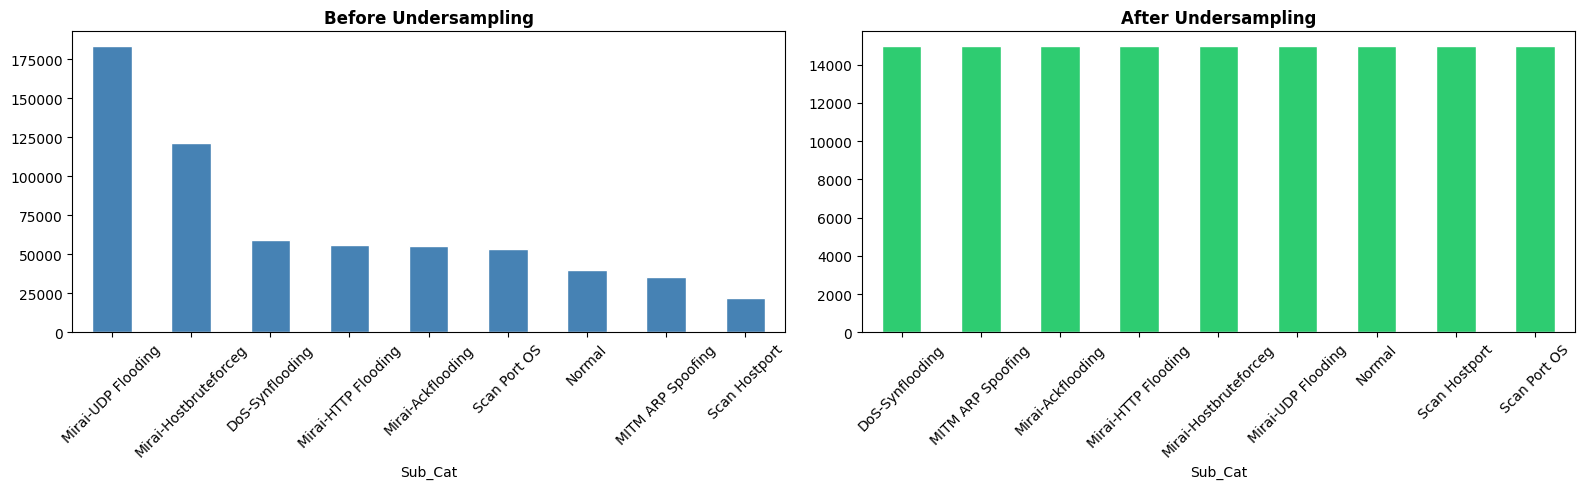


Dropping leakage columns: ['Label', 'Cat']
Numeric features: 79

Classes (9): ['DoS-Synflooding', 'MITM ARP Spoofing', 'Mirai-Ackflooding', 'Mirai-HTTP Flooding', 'Mirai-Hostbruteforceg', 'Mirai-UDP Flooding', 'Normal', 'Scan Hostport', 'Scan Port OS']

Split sizes:
  Train : 94,500 (70.0%)
  Val   : 13,500   (10.0%)
  Test  : 27,000  (20.0%)

Features after preprocessing: 79
 Preprocessing complete — no data leakage


In [6]:
# CELL 5 — UNDERSAMPLE + PREPROCESS (NO DATA LEAKAGE)

print(f'Undersampling each class to {UNDERSAMPLE_TO:,} rows...')

df_balanced = (
    df.groupby(LABEL_COL)
    .apply(lambda x: x.sample(
        min(len(x), UNDERSAMPLE_TO),
        random_state=RANDOM_STATE))
    .reset_index(drop=True)
)

print(f'\nBalanced dataset shape: {df_balanced.shape}')
print(f'\nBalanced label distribution:')
print(df_balanced[LABEL_COL].value_counts())

# Before/After plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
df[LABEL_COL].value_counts().plot.bar(ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Before Undersampling', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
df_balanced[LABEL_COL].value_counts().plot.bar(ax=axes[1], color='#2ecc71', edgecolor='white')
axes[1].set_title('After Undersampling', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR, 'before_after_balance.png'), dpi=150, bbox_inches='tight')
plt.show()

# Drop leakage columns
DROP_COLS = ['Label', 'Cat', 'Attack_type', 'Attack_subType']
cols_to_drop = [c for c in DROP_COLS if c in df_balanced.columns]
print(f'\nDropping leakage columns: {cols_to_drop}')

X_raw = df_balanced.drop(columns=[LABEL_COL] + cols_to_drop)
y_raw = df_balanced[LABEL_COL].copy()

# Keep numeric only + replace inf
X_raw = X_raw.select_dtypes(include=[np.number])
X_raw.replace([np.inf, -np.inf], np.nan, inplace=True)
print(f'Numeric features: {X_raw.shape[1]}')

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)
print(f'\nClasses ({len(le.classes_)}): {list(le.classes_)}')

# Split: 70% train / 10% val / 20% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X_raw, y_encoded,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=2/3,             # 20% out of 30% = 2/3 of temp
    random_state=RANDOM_STATE,
    stratify=y_temp
)

total = len(df_balanced)
print(f'\nSplit sizes:')
print(f'  Train : {len(X_train):,} ({len(X_train)/total*100:.1f}%)')
print(f'  Val   : {len(X_val):,}   ({len(X_val)/total*100:.1f}%)')
print(f'  Test  : {len(X_test):,}  ({len(X_test)/total*100:.1f}%)')

# Impute median on TRAIN only
train_median = X_train.median()
X_train = X_train.fillna(train_median)
X_val   = X_val.fillna(train_median)
X_test  = X_test.fillna(train_median)

# Scale on TRAIN only
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_val_s   = scaler.transform(X_val).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

n_features = X_train_s.shape[1]
n_classes  = len(le.classes_)
print(f'\nFeatures after preprocessing: {n_features}')
print(' Preprocessing complete — no data leakage')

In [7]:
# CELL 6 — EVALUATION HELPER

def evaluate_model(model_name, y_true, y_pred, out_dir):
    acc  = accuracy_score(y_true, y_pred)
    f1m  = f1_score(y_true, y_pred, average='macro',    zero_division=0)
    f1w  = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f"\n{'='*55}")
    print(f'  {model_name} — Results')
    print(f"{'='*55}")
    print(f'  Accuracy      : {acc:.4f}')
    print(f'  F1 (macro)    : {f1m:.4f}')
    print(f'  F1 (weighted) : {f1w:.4f}')
    print(f'\n{classification_report(y_true, y_pred, target_names=le.classes_, zero_division=0)}')

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'{model_name} — Confusion Matrix (IoTID20 Balanced)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    path = os.path.join(out_dir, f"{model_name.lower().replace(' ','_')}_confusion_matrix.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f'Saved: {path}')

    return {'model': model_name, 'accuracy': acc,
            'f1_macro': f1m, 'f1_weighted': f1w}

In [8]:
# CELL 7 — TRAIN RealMLP

print('Training RealMLP on IoTID20 (balanced)...')

realmlp = RealMLP_TD_Classifier(
    device='cuda',
    random_state=RANDOM_STATE,
    verbosity=1,
    n_cv=1,
    n_refit=0,
)

realmlp.fit(X_train_s, y_train, X_val=X_val_s, y_val=y_val)
print(' RealMLP training complete')

Training RealMLP on IoTID20 (balanced)...
Columns classified as continuous: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78]
Columns classified as categorical: []


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=256` reached.


 RealMLP training complete


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cud

RealMLP | Train | Acc: 0.8031 | F1 Macro: 0.8071

  RealMLP — Results
  Accuracy      : 0.7648
  F1 (macro)    : 0.7696
  F1 (weighted) : 0.7696

                       precision    recall  f1-score   support

      DoS-Synflooding       1.00      1.00      1.00      3000
    MITM ARP Spoofing       0.92      0.95      0.94      3000
    Mirai-Ackflooding       0.42      0.54      0.47      3000
  Mirai-HTTP Flooding       0.42      0.41      0.41      3000
Mirai-Hostbruteforceg       0.91      0.86      0.88      3000
   Mirai-UDP Flooding       0.97      0.71      0.82      3000
               Normal       0.99      0.99      0.99      3000
        Scan Hostport       0.77      0.62      0.69      3000
         Scan Port OS       0.66      0.80      0.73      3000

             accuracy                           0.76     27000
            macro avg       0.78      0.76      0.77     27000
         weighted avg       0.78      0.76      0.77     27000



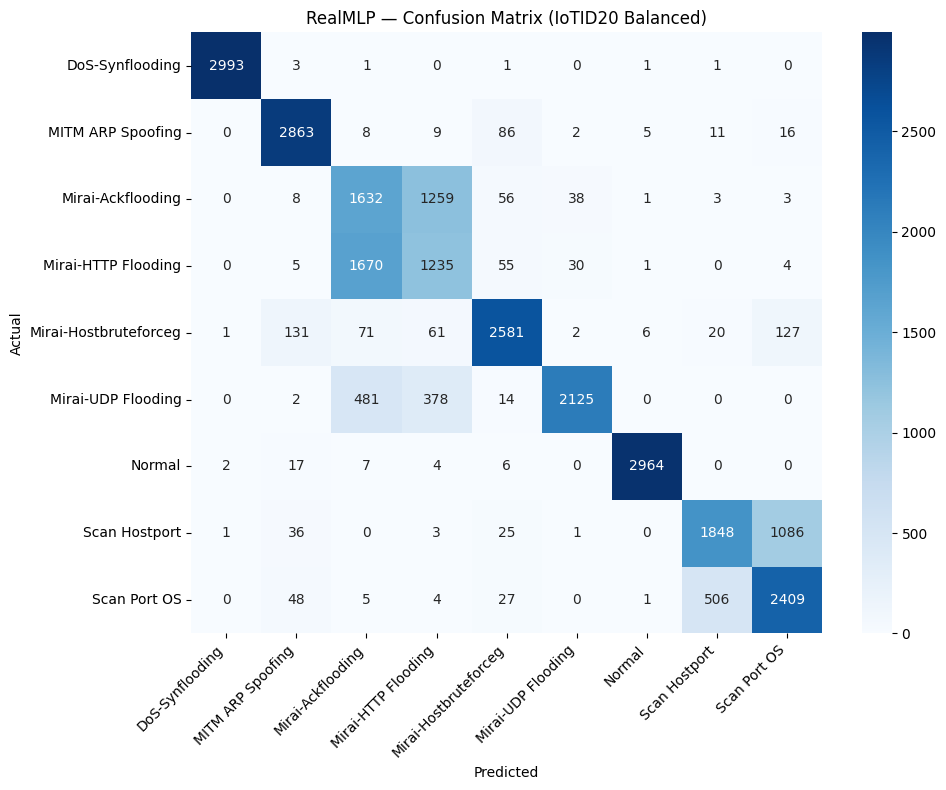

Saved: /content/drive/MyDrive/iotid20_outputs/realmlp_confusion_matrix.png


In [9]:
# ============================================================
# CELL 8 — EVALUATE RealMLP
# ============================================================
realmlp_train_preds = realmlp.predict(X_train_s)
train_acc = accuracy_score(y_train, realmlp_train_preds)
train_f1  = f1_score(y_train, realmlp_train_preds, average='macro', zero_division=0)
print(f'RealMLP | Train | Acc: {train_acc:.4f} | F1 Macro: {train_f1:.4f}')

realmlp_test_preds = realmlp.predict(X_test_s)
realmlp_results = evaluate_model('RealMLP', y_test, realmlp_test_preds, DRIVE_OUT_DIR)
realmlp_results['train_acc'] = train_acc
realmlp_results['train_f1']  = train_f1

In [11]:
from tabm import TabM

train_dl = DataLoader(
    TensorDataset(
        torch.tensor(X_train_s),
        torch.tensor(y_train, dtype=torch.long)),
    batch_size=BATCH_SIZE, shuffle=True)

val_dl = DataLoader(
    TensorDataset(
        torch.tensor(X_val_s),
        torch.tensor(y_val, dtype=torch.long)),
    batch_size=BATCH_SIZE, shuffle=False)

tabm_model = TabM.make(
    n_num_features=n_features,
    cat_cardinalities=[],
    d_out=n_classes,
).to(device)

optimizer = torch.optim.AdamW(
    tabm_model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.CrossEntropyLoss()

print(f'TabM params  : {sum(p.numel() for p in tabm_model.parameters()):,}')
print(f'Max epochs   : {N_EPOCHS_TABM}')
print('Training TabM on IoTID20 (balanced)...')

best_val_f1      = 0
best_state       = None
tabm_history     = []
# Early stopping  removed

for epoch in range(1, N_EPOCHS_TABM + 1):
    tabm_model.train()
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(tabm_model(xb).mean(dim=1), yb)
        loss.backward()
        optimizer.step()

    tabm_model.eval()
    preds_all, true_all = [], []
    with torch.no_grad():
        for xb, yb in val_dl:
            p = (tabm_model(xb.to(device))
                 .mean(dim=1).argmax(dim=-1).cpu().numpy())
            preds_all.extend(p)
            true_all.extend(yb.numpy())

    val_f1  = f1_score(true_all, preds_all, average='macro', zero_division=0)
    val_acc = accuracy_score(true_all, preds_all)
    tabm_history.append({'epoch': epoch, 'val_f1': val_f1, 'val_acc': val_acc})

    if epoch % 10 == 0 or epoch == 1:
        print(f'  Epoch {epoch:03d}/{N_EPOCHS_TABM} | '
              f'Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}')

    if val_f1 > best_val_f1:
        best_val_f1      = val_f1
        best_state       = {k: v.cpu() for k, v in tabm_model.state_dict().items()}

print(f'\nBest Val F1 (TabM): {best_val_f1:.4f} ')

TabM params  : 846,080
Max epochs   : 256
Training TabM on IoTID20 (balanced)...
  Epoch 001/256 | Val Acc: 0.5795 | Val F1: 0.5835
  Epoch 010/256 | Val Acc: 0.6884 | Val F1: 0.6870
  Epoch 020/256 | Val Acc: 0.6921 | Val F1: 0.6979
  Epoch 030/256 | Val Acc: 0.7076 | Val F1: 0.7062
  Epoch 040/256 | Val Acc: 0.7050 | Val F1: 0.7045
  Epoch 050/256 | Val Acc: 0.7158 | Val F1: 0.7084
  Epoch 060/256 | Val Acc: 0.7227 | Val F1: 0.7287
  Epoch 070/256 | Val Acc: 0.7174 | Val F1: 0.7215
  Epoch 080/256 | Val Acc: 0.7136 | Val F1: 0.7188
  Epoch 090/256 | Val Acc: 0.7228 | Val F1: 0.7267
  Epoch 100/256 | Val Acc: 0.7250 | Val F1: 0.7272
  Epoch 110/256 | Val Acc: 0.7233 | Val F1: 0.7225
  Epoch 120/256 | Val Acc: 0.7225 | Val F1: 0.7283
  Epoch 130/256 | Val Acc: 0.7206 | Val F1: 0.7250
  Epoch 140/256 | Val Acc: 0.7344 | Val F1: 0.7358
  Epoch 150/256 | Val Acc: 0.7289 | Val F1: 0.7335
  Epoch 160/256 | Val Acc: 0.7259 | Val F1: 0.7186
  Epoch 170/256 | Val Acc: 0.7211 | Val F1: 0.7182
 

TabM | Train | Acc: 0.7574 | F1 Macro: 0.7624

  TabM — Results
  Accuracy      : 0.7273
  F1 (macro)    : 0.7332
  F1 (weighted) : 0.7332

                       precision    recall  f1-score   support

      DoS-Synflooding       1.00      1.00      1.00      3000
    MITM ARP Spoofing       0.87      0.93      0.90      3000
    Mirai-Ackflooding       0.43      0.44      0.43      3000
  Mirai-HTTP Flooding       0.42      0.54      0.47      3000
Mirai-Hostbruteforceg       0.90      0.81      0.85      3000
   Mirai-UDP Flooding       0.98      0.71      0.82      3000
               Normal       0.99      0.99      0.99      3000
        Scan Hostport       0.57      0.56      0.57      3000
         Scan Port OS       0.56      0.58      0.57      3000

             accuracy                           0.73     27000
            macro avg       0.75      0.73      0.73     27000
         weighted avg       0.75      0.73      0.73     27000



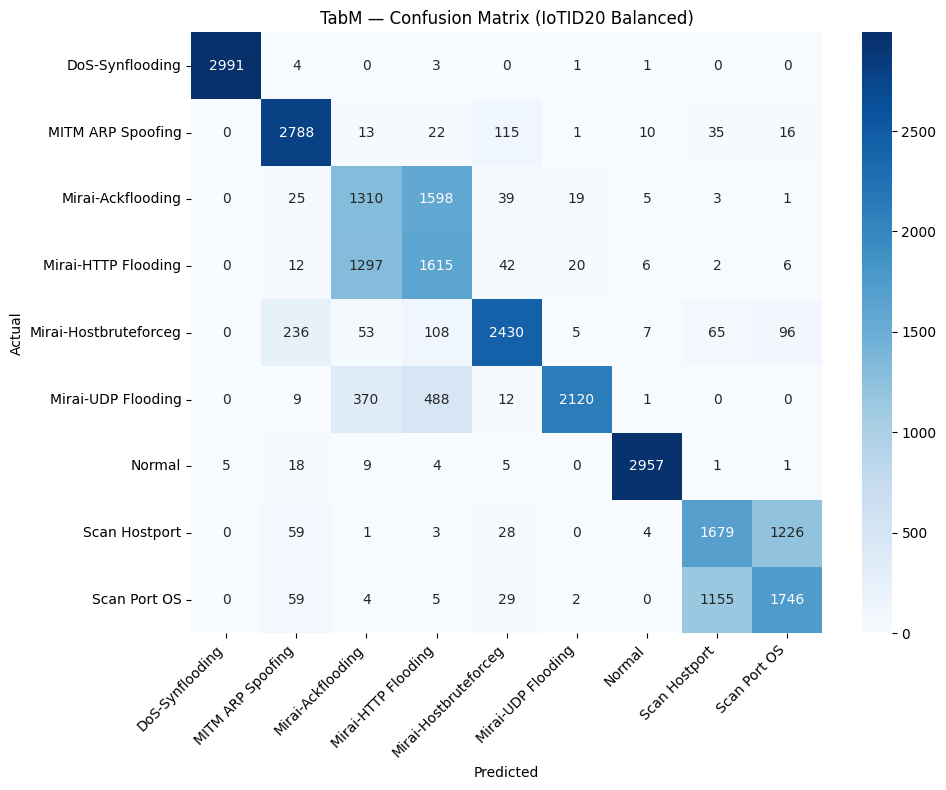

Saved: /content/drive/MyDrive/iotid20_outputs/tabm_confusion_matrix.png


In [12]:
# CELL 10 — EVALUATE TabM

tabm_model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
tabm_model.eval()

test_dl = DataLoader(
    TensorDataset(
        torch.tensor(X_test_s),
        torch.tensor(y_test, dtype=torch.long)),
    batch_size=BATCH_SIZE, shuffle=False)

preds_all, true_all = [], []
with torch.no_grad():
    for xb, yb in test_dl:
        p = (tabm_model(xb.to(device))
             .mean(dim=1).argmax(dim=-1).cpu().numpy())
        preds_all.extend(p)
        true_all.extend(yb.numpy())

train_eval_dl = DataLoader(
    TensorDataset(
        torch.tensor(X_train_s),
        torch.tensor(y_train, dtype=torch.long)),
    batch_size=BATCH_SIZE, shuffle=False)

train_preds = []
with torch.no_grad():
    for xb, yb in train_eval_dl:
        p = (tabm_model(xb.to(device))
             .mean(dim=1).argmax(dim=-1).cpu().numpy())
        train_preds.extend(p)

train_acc = accuracy_score(y_train, train_preds)
train_f1  = f1_score(y_train, train_preds, average='macro', zero_division=0)
print(f'TabM | Train | Acc: {train_acc:.4f} | F1 Macro: {train_f1:.4f}')

tabm_results = evaluate_model('TabM', true_all, preds_all, DRIVE_OUT_DIR)
tabm_results['train_acc'] = train_acc
tabm_results['train_f1']  = train_f1


===== FINAL RESULTS — IoTID20 (Balanced) =====
  model  train_acc  accuracy  train_f1  f1_macro  f1_weighted
RealMLP   0.803101  0.764815  0.807098  0.769641     0.769641
   TabM   0.757386  0.727259  0.762449  0.733187     0.733187

Results saved: /content/drive/MyDrive/iotid20_outputs/iotid20_balanced_results.csv


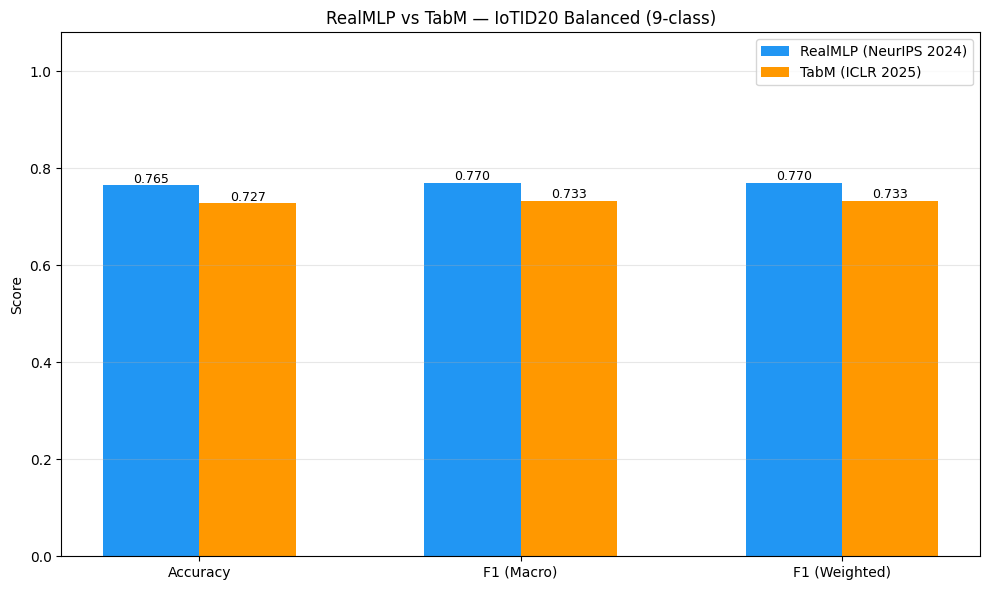

Chart saved: /content/drive/MyDrive/iotid20_outputs/iotid20_balanced_comparison.png


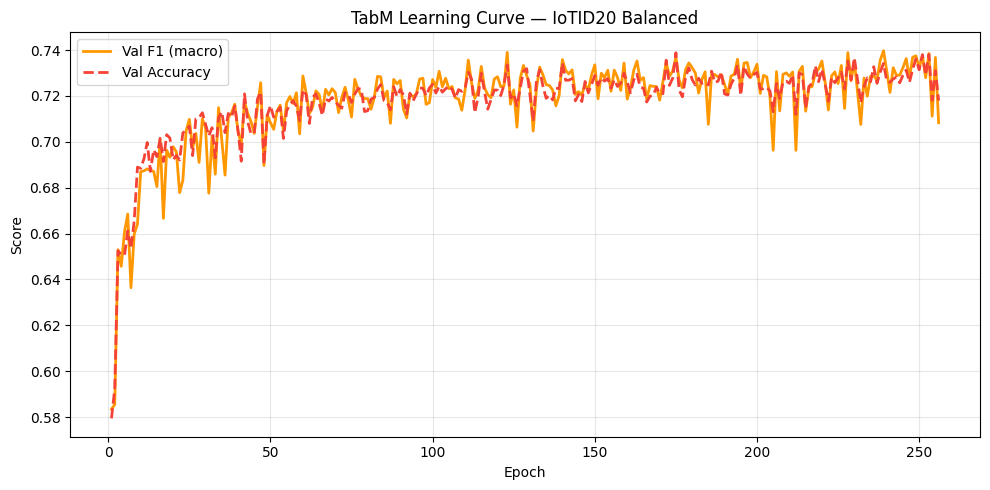

Learning curve saved: /content/drive/MyDrive/iotid20_outputs/iotid20_balanced_tabm_curve.png

 All outputs saved to Drive!


In [14]:
# CELL 11 — COMPARISON + SAVE

results_df = pd.DataFrame([realmlp_results, tabm_results])
print('\n===== FINAL RESULTS — IoTID20 (Balanced) =====')
print(results_df[['model', 'train_acc', 'accuracy',
                   'train_f1', 'f1_macro', 'f1_weighted']].to_string(index=False))

csv_path = os.path.join(DRIVE_OUT_DIR, 'iotid20_balanced_results.csv')
results_df.to_csv(csv_path, index=False)
print(f'\nResults saved: {csv_path}')

# Comparison bar chart
metrics      = ['accuracy', 'f1_macro', 'f1_weighted']
metric_names = ['Accuracy', 'F1 (Macro)', 'F1 (Weighted)']
x     = np.arange(len(metrics))
width = 0.3

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2,
               [realmlp_results[m] for m in metrics],
               width, label='RealMLP (NeurIPS 2024)', color='#2196F3')
bars2 = ax.bar(x + width/2,
               [tabm_results[m] for m in metrics],
               width, label='TabM (ICLR 2025)', color='#FF9800')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1.08)
ax.set_ylabel('Score')
ax.set_title('RealMLP vs TabM — IoTID20 Balanced (9-class)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
chart_path = os.path.join(DRIVE_OUT_DIR, 'iotid20_balanced_comparison.png')
plt.savefig(chart_path, dpi=150)
plt.show()
print(f'Chart saved: {chart_path}')

# TabM learning curve
fig, ax = plt.subplots(figsize=(10, 5))
epochs = [h['epoch']   for h in tabm_history]
f1s    = [h['val_f1']  for h in tabm_history]
accs   = [h['val_acc'] for h in tabm_history]
ax.plot(epochs, f1s,  label='Val F1 (macro)', color='#FF9800', linewidth=2)
ax.plot(epochs, accs, label='Val Accuracy', color='#F44336', linewidth=2, linestyle='--')
ax.set_xlabel('Epoch')
ax.set_ylabel('Score')
ax.set_title('TabM Learning Curve — IoTID20 Balanced')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
curve_path = os.path.join(DRIVE_OUT_DIR, 'iotid20_balanced_tabm_curve.png')
plt.savefig(curve_path, dpi=150)
plt.show()
print(f'Learning curve saved: {curve_path}')
print('\n All outputs saved to Drive!')